# Punto 4 (0.6) — Detección de bordes (Sobel y Laplaciano)

Con su imagen original en escala de grises, use los operadores de Sobel y Laplaciano con convolución para detección de bordes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import sys
sys.path.append("..")


## Kernels

Sobel Horizontal:
```
1  2  1
0  0  0
-1 -2 -1
```

Sobel Vertical:
```
1  0 -1
2  0 -2
1  0 -1
```

Laplaciano 8 vecinos:
```
1  1  1
1 -8  1
1  1  1
```

In [2]:
sobel_h = np.array([[1, 2, 1], [0, 0, 0], [-1, -2, -1]], dtype=np.float64)
sobel_v = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]], dtype=np.float64)
laplaciano_8 = np.array([[1, 1, 1], [1, -8, 1], [1, 1, 1]], dtype=np.float64)

def convolucion(im, kernel):
    kernel_flip = kernel[::-1, ::-1]
    return cv2.filter2D(im, -1, kernel_flip, borderType=cv2.BORDER_REPLICATE)

img = np.array(Image.open("../images/mi_imagen.png").convert("RGB"))
gray = np.array(Image.fromarray(img).convert("L")).astype(np.float64)


## Sobel — magnitud del gradiente

Incorpore aquí la imagen resultante de aplicar los filtros de Sobel mediante convolución y calcular la magnitud del gradiente mediante la aproximación por suma de valores absolutos.

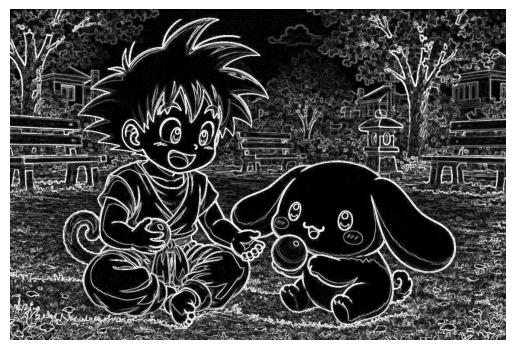

In [3]:
gx = convolucion(gray, sobel_h)
gy = convolucion(gray, sobel_v)

sobel_magnitud = np.clip(np.abs(gx) + np.abs(gy), 0, 255).astype(np.uint8)

plt.imshow(sobel_magnitud, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_sobel_magnitud.png", bbox_inches="tight", pad_inches=0)


## Laplaciano de 8 vecinos

Incorpore aquí la imagen resultante tras aplicar el Laplaciano de 8 vecinos.

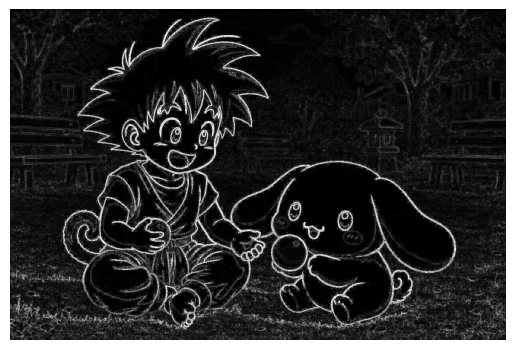

In [4]:
laplaciano_conv = convolucion(gray, laplaciano_8)
laplaciano_resultado = np.clip(np.abs(laplaciano_conv), 0, 255).astype(np.uint8)

plt.imshow(laplaciano_resultado, cmap="gray")
plt.axis("off")
plt.savefig("../results/punto4_laplaciano.png", bbox_inches="tight", pad_inches=0)
